# Project Goal: To find out the most popular make up brand that people purchase online.

**Background and Motivation:** 
In recent years, the rapid expansion of e-commerce has significantly transformed how consumers research and purchase beauty products. The cosmetic industry, in particular, whether it is a globally recognised brand or an emerging niche brand, has embraced online retail format. This makes their cosmetics more accessible to shoppers all around the world. E‑commerce platforms have leveled the playing field for smaller and emerging cosmetic brands. Unlike traditional retail, where shelf space is limited, online marketplaces give every brand a chance to be seen and reviewed by consumers.

In this project, we shall aim to identify the makeup brands that stand out in today’s online marketplace. The insights gained will not only highlight consumer favorites but also explore how online platforms influence brand success in the cosmetics industry.

In [1]:
!pip install pandas
!pip install seaborn
!pip install matplotlib.pyplot

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Loading Dataset

I will be using the E-commerce Cosmetic dataset for this project. It is retrieved from Kaggle, https://www.kaggle.com/datasets/devi5723/e-commerce-cosmetics-dataset?resource=download

In [3]:
df = pd.read_csv("ecommerce_cosmetic_data.csv", encoding="latin1")
print("\nData preview:")
display(df.head())


Data preview:


,product_name,website,country,category,subcategory,title-href,price,brand,ingredients,form,type,color,size,rating,noofratings
0,"Carlton London Incense Eau da parfum, Premium ...",Flipkart,India,body,perfume,https://www.amazon.in/Carlton-London-Limited-I...,599.0,Carlton London,NaN,aerosol,NaN,"Top Note: Orange Blossom, Blackberry | Heart N...",100,3.9,19
1,CHARLENE SPRAY MIST PERFUME 30 - INTIMATE (PAC...,Flipkart,India,body,perfume,https://www.amazon.in/CHARLENE-SPRAY-MIST-PERF...,149.0,Charlene,NaN,aerosol,NaN,Unit count type:,30,4.4,"4,031"
2,CHARLENE SPRAY MIST PERFUME 30 - INTIMATE (PAC...,Flipkart,India,body,perfume,https://www.amazon.in/CHARLENE-SPRAY-MIST-PERF...,298.0,Charlene,NaN,aerosol,NaN,Unit count type:,30,4.4,"4,072"
3,DENVER Black Code Perfume - 60 | Eau de Parfum...,Flipkart,India,body,perfume,https://www.amazon.in/DENVER-Black-Code-Perfum...,245.0,Denver,NaN,aerosol,NaN,Long-Lasting Scent,60,4.2,61
4,Denver Hamilton Perfume - 100 | Long Lasting P...,Flipkart,India,body,perfume,https://www.amazon.in/Denver-Perfume-Hamilton-...,422.0,Denver,NaN,aerosol,NaN,Long-Lasting Scent,100,4.3,342


In [4]:
print("\nInfo:")
print(df.info())
print("\nshape:")
print(df.shape)

df.describe(include='all')


Info:
<class 'pandas.DataFrame'>
RangeIndex: 12615 entries, 0 to 12614
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  12615 non-null  str    
 1   website       12615 non-null  str    
 2   country       12615 non-null  str    
 3   category      12615 non-null  str    
 4   subcategory   12615 non-null  str    
 5   title-href    12615 non-null  str    
 6   price         12298 non-null  float64
 7   brand         12615 non-null  str    
 8   ingredients   6600 non-null   str    
 9   form          12615 non-null  str    
 10  type          9934 non-null   str    
 11  color         10626 non-null  str    
 12  size          9449 non-null   str    
 13  rating        10548 non-null  str    
 14  noofratings   12156 non-null  str    
dtypes: float64(1), str(14)
memory usage: 1.4 MB
None

shape:
(12615, 15)


,product_name,website,country,category,subcategory,title-href,price,brand,ingredients,form,type,color,size,rating,noofratings
count,12615,12615,12615,12615,12615,12615,12298.000000,12615,6600,12615,9934,10626,9449,10548,12156
unique,11341,5,2,6,36,12244,NaN,1753,4839,25,133,3357,700,253,2096
top,Even Better All-Over Concealer + Eraser -,Amazon,India,body,perfume,https://sephora.nnnow.com/lip-liner?p=1&f-co=p...,NaN,Sephora Collection,"Avocado , Resins, Jellifying Agents, Vitamin E...",liquid,all,No color,30,4.3,0
freq,16,4749,8908,2555,1502,19,NaN,482,64,5298,5158,4197,835,757,686
mean,NaN,NaN,NaN,NaN,NaN,NaN,2281.180935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,3158.690307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,499.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1307.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2859.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2) Exploratory Data Analysis

In [5]:
print('Statistics for Rating:')
print(f"Min: {df['rating'].min()}, Max: {df['rating'].max()}")

df['rating'] = pd.to_numeric(df['rating'], errors='coerce').dropna()
(df['rating']>5).sum()

df_clean = df[df['rating']<5]
df_clean.shape

Statistics for Rating:
Min: 1, Max: 95


(10092, 15)

In [6]:
df_clean.describe(include='all')

,product_name,website,country,category,subcategory,title-href,price,brand,ingredients,form,type,color,size,rating,noofratings
count,10092,10092,10092,10092,10092,10092,9946.000000,10092,6192,10092,7872,8257,8104,10092.000000,10061
unique,8927,5,2,6,34,9737,NaN,1249,4565,24,109,3037,638,NaN,1968
top,Even Better All-Over Concealer + Eraser -,ulta,India,body,perfume,https://sephora.nnnow.com/lip-liner?p=1&f-co=p...,NaN,Sephora Collection,"Avocado , Resins, Jellifying Agents, Vitamin E...",liquid,all,No color,30,NaN,14
freq,16,3395,6697,2199,1326,19,NaN,482,64,4142,3825,2932,820,NaN,317
mean,NaN,NaN,NaN,NaN,NaN,NaN,2495.748541,NaN,NaN,NaN,NaN,NaN,NaN,4.104602,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,3176.060222,NaN,NaN,NaN,NaN,NaN,NaN,0.506862,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,3.500000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,614.425000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1634.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.200000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,3186.300000,NaN,NaN,NaN,NaN,NaN,NaN,4.400000,NaN


In [7]:
# Due to the large number of brands we have in this dataset, we are going to show only the top 10 brands
top_10 = df_clean['brand'].value_counts().head(10)
df_top_10 = df_clean[df_clean['brand'].isin(top_10.index)]

# 3) Visualisations

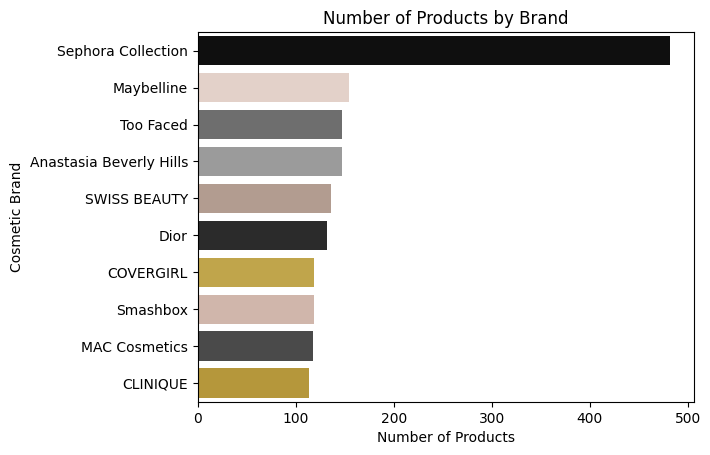

In [8]:
palette2 = ['#0f0f0f', '#2b2b2b', '#4a4a4a', '#6e6e6e', '#9b9b9b', '#c9a227', '#d4af37', '#e8cfc4', '#d6b3a5', '#b89a8a']

sns.countplot(data = df_top_10, y='brand', hue='brand', order = top_10.index, palette = palette2, legend=False, linewidth=0.8)
plt.xlabel('Number of Products')
plt.ylabel('Cosmetic Brand')
plt.title('Number of Products by Brand')
plt.show()

The bar graph shows the brands with the most diverse product range. Usually, brands that offer a larger variety of products are seen as more complete and have a stronger presence. This can be an early indicator of popularity and brand reach. As shown in the results, the top 10 brands are ones I personally recognize and have seen frequently online. This aligns with my own experience of popular makeup brands having a wide range of products.

I chose bar plot because it provides a clear and straightforward visualisation. 

Limitation: While the bar plot shows effectively the number of type of products per brand, it could not provide more information about consumer's popularity. The bar plot also cannot display all the brands due to space limitation, this leaves small and niche brands unrepresented. 

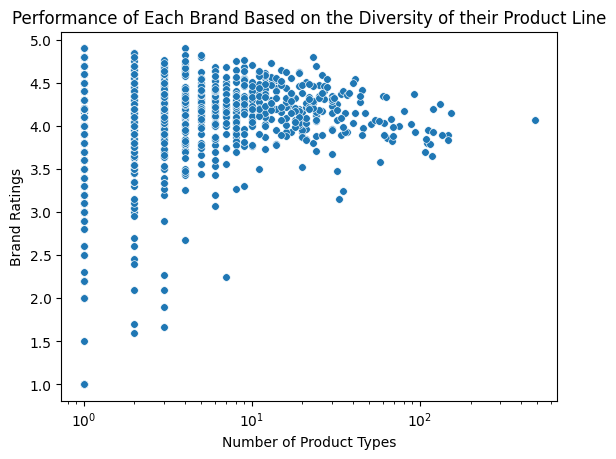

In [10]:
no_of_pdt_type_all = df_clean.groupby('brand')['category'].count()
brand_rating_all = df_clean.groupby('brand')['rating'].mean()

# Compute average ratings for all brands
sns.scatterplot(x = no_of_pdt_type_all.values, y = brand_rating_all.values, s = 30, )
plt.xscale('log')
plt.xlabel('Number of Product Types')
plt.ylabel('Brand Ratings')
plt.title('Performance of Each Brand Based on the Diversity of their Product Line')
plt.show()

As the variety of makeup products offered by brands increases, the average ratings tend to converge toward a middle range. In contrast, brands with a smaller product variety show a wider spread of ratings, suggesting that niche or focused brands can achieve both very high and very low ratings depending on individual products.

Limitation: It is hard to identify the individual brands since the scatters are not annotated. 

<function matplotlib.pyplot.show(close=None, block=None)>

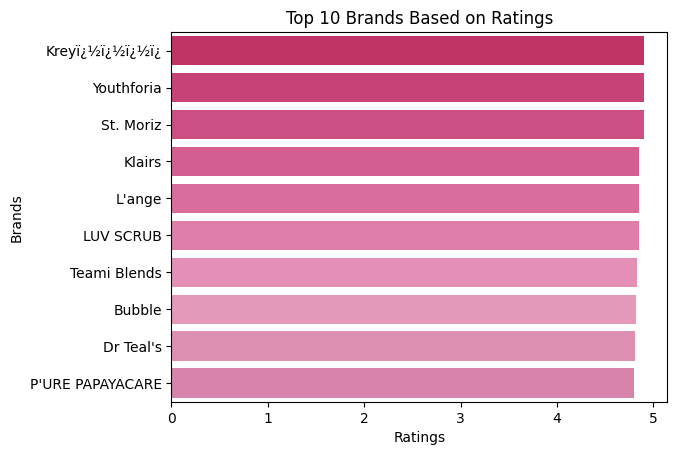

In [37]:
top_10_rated = df_clean.groupby('brand')['rating'].mean().sort_values(ascending = False).head(10).reset_index()
# changing pandas series into a dataframe for sns.barplot to work
top_10_rated.columns = ['Brands', 'Ratings']

palette1 = ['#d81b60', '#dd2c72', '#e03a7f', '#e64b8d', '#eb5c9a', '#ef6fa7', '#f282b4', '#f08db8', '#ea82b1', '#e377a9']
sns.barplot(data = top_10_rated, y = 'Brands', x = 'Ratings',  hue = 'Brands', palette = palette1, legend=False)
plt.xlabel('Ratings')
plt.ylabel('Brands')
plt.title('Top 10 Brands Based on Ratings')
plt.show

Interestingly, the top 10 brands based on ratings include several niche brands, while some of the larger, well-known brands do not appear. This could be because brands with a wider variety of products may have their ratings diluted across many items, whereas niche brands often have a smaller, more focused product line that receives higher average ratings.